<span style="color:red">Work in progress</span>

--> This jupyter notebook serve as the basic structure to perform life cycle assessment within our research group (Used at least by Augustin & Robin).

# Introduction

The architecture of this notebook is explained in the Figure bellow that depicts the three different type of brightway2 (BW2) databases that are used in the notebook:
- the biosphere database from ecoinvent
- the original ecoinvent database version 3.9.1 cutoff
- an Open Source (OS) database where custom activities are created.

This jupyter notebook does the following:
1. Create the BW2 environment to compute the LCA
2. Generate the foreground activities, custom activities and modified activies in the framework of LCA algebraic using several excel file as data input
3. Compute LCIA results with uncertainty and distribution based on parameter distributions.

The following figure illustrates the database structure of this BW2 notebook and the purpose of the various files used.

![title](image/figure_notebook_structure.png)


# Importing relevant packages

In [1]:
import brightway2 as bw
import lca_algebraic as agb
from sympy import init_printing
import bw2io
from dotenv import load_dotenv
import pandas as pd
from sympy import symbols
import logging
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os 
import json
from importlib import reload
import yaml
from pathlib import Path

In [2]:
from src.ei_access import EI_Access
from src.ei_access.setup import setup_ecoinvent_database
from src.utils.sheets_parser import find_activity,process_parameters,create_custom_activities,create_foreground

# Parameters

In [3]:

#### Project & ecoinvent database parameters
project_name= 'ECS-LCA'

ei_acc = EI_Access()

#### Life cycle data parameters
xlsx_path = "./sheets/"
yaml_path = "./yaml/"
# This Excel file must be formatted according to the provided template.
LC_data_Foreground_file_path = xlsx_path + "LC_data_Foreground.xlsx"
foreground_list=["foreground_ICT_2024_BE"] #These foreground can represent different scenario for example

#Specify the files that contain the data to build the custom and modified activities.
custom_meta_data_YAML = yaml_path + "custom_meta_data_YAML.xlsx"

# Specify the Foreground for which the results will be computed
selected_foreground = 'foreground_ICT_2024_BE' 

# Specify the LCIA method with which the results will be computed
impacts_GWP_specific=('EF v3.1', 'climate change', 'global warming potential (GWP100)')
#impacts_GWP_specific=('CML v4.8 2016 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
impacts_ADP_specific=('EF v3.1', 'material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserves)')
LCIA_method_list=[impacts_GWP_specific,impacts_ADP_specific]
#Specify amoung which label the contribution analysis should be performed:
contribution_analysis_label = "LC phase"


#Specify the output folder to export the results
output_folder = r"./results"

In [4]:
bw.projects

Brightway2 projects manager with 2 objects:
	ECS-LCA
	default
Use `projects.report()` to get a report on all projects.

# Initialize the project and the ecoinvent database

In [5]:
# Uncomment and run only if you think you messed up your project
#bw.projects.delete_project(name=project_name, delete_dir=True)

In [6]:
bw.projects.set_current(project_name) # Set the current project, can be any name

In [7]:
if 'biosphere3' not in bw.databases.keys():
    #Content of bw2.setup() function but with overwrite=True
    bw.create_default_biosphere3()
    bw.create_default_lcia_methods(overwrite=True)
    bw.create_core_migrations()

In [8]:
#setup_ecoinvent_database(ei_acc)

In [9]:
agb.list_databases()

,backend,nb_activities,type
name,,,
biosphere3,sqlite,4709,biosphere
ecoinvent-3.11-biosphere,sqlite,9795,biosphere
ecoinvent-3.11-cutoff,sqlite,25412,background
OS database,sqlite,6,foreground


# Load the life-cycle data (foreground systems, created and modified activities)

In [10]:
# Loading the foreground systems in a dictionnary
foregrounds_All = {}
for foreground_name in foreground_list:
    foreground=pd.read_excel(LC_data_Foreground_file_path, sheet_name=foreground_name)
    foregrounds_All[foreground_name]=foreground

In [11]:
custom_meta_data_YAML_DF=pd.read_excel(custom_meta_data_YAML)
custom_meta_data_YAML_DF=custom_meta_data_YAML_DF.set_index('file')
config = yaml.safe_load(open(yaml_path + "config.yaml"))

In [12]:
def load_custom_activities(yaml_path):
    custom_root = Path(yaml_path) / "custom"
    activities = []

    for file in custom_root.rglob("*.yaml"):
        with open(file, "r") as f:
            data = yaml.safe_load(f)
            activity = data["custom_activity"]
            # preserve category structure
            relative_path = file.relative_to(custom_root)
            activity["folder"] = relative_path.parent.as_posix()
            activities.append(activity)
            
    return activities

In [13]:
def generate_parameter_registry(activities):

    with open(yaml_path + "config.yaml", "r") as f:
        config = yaml.safe_load(f)

    registry = {}

    uncertainty_cfg = config.get("uncertainty", {})
    global_default_value = uncertainty_cfg.get("default_value")
    global_default_distribution = uncertainty_cfg.get("default_distribution")

    for activity in activities:
        activity_id = activity["id"]

        for input_ in activity.get("inputs", []):

            amount = input_.get("amount")
            if not isinstance(amount, dict):
                continue

            param_name = amount["parameter"]
            namespaced = f"{activity_id}_{param_name}"

            if namespaced in registry:
                raise ValueError(f"Duplicate parameter: {namespaced}")

            if "typical" in amount:
                typical_value = amount["typical"]
                uncertainty_block = amount.get("uncertainty", {})
                if uncertainty_block:
                    distribution = uncertainty_block.get(
                        "distribution",
                        global_default_distribution
                    )
                else:
                    distribution = global_default_distribution
            else:
                typical_value = global_default_value
                distribution = global_default_distribution
            

            registry[namespaced] = {
                "source_activity": activity_id,
                "typical": typical_value,
                "distribution": distribution,
                "uncertainty": uncertainty_block,
            }

    return registry

In [14]:
class ParamGroup:
    def __init__(
        self,
        variables,
        total,
        sd_total, 
        min_aggregate = 0,
        max_aggregate = np.inf,
        shares_disaggregates=None,
        sds_shares=None,
    ):
        self.variables = variables
        self.total = total
        self.sd_total = sd_total
        self.min_aggregate = min_aggregate
        self.max_aggregate = max_aggregate
        self.shares_disaggregates = shares_disaggregates
        self.sds_shares = sds_shares



def param_groups_from_activity(activity):
    activity_name = activity.get("id", {})
    groups_yaml = activity.get("groups", {})
    inputs = activity.get("inputs", [])

    param_groups = []
    variables = []

    for group_id, group_data in groups_yaml.items():

        total = group_data["total"]["typical"]
        sd_total = group_data["total"].get("sd")
        #variables = []
        typicals = []
        sds = []

        for inp in inputs:

            if inp.get("group") != group_id:
                continue
            amount = inp.get("amount", {})
            param = amount.get("parameter")
            typical = amount.get("typical")

            if param is None or typical is None:
                continue

            param_complete = f"{activity_name}_{param}"

            variables.append(param_complete)
            typicals.append(typical)

            sd = inp.get("uncertainty", {}).get("sd_share")
            sds.append(sd)

        shares = [t / total for t in typicals]

        param_groups.append(
            ParamGroup(
                variables=variables,
                total=total,
                sd_total=sd_total,
                shares_disaggregates=shares,
                sds_shares=sds
            )
        )

    return param_groups, variables


def param_groups_from_activities(activities):

    all_groups = []
    group_param_variables = []

    for activity in activities:
        groups, variables = param_groups_from_activity(activity)
        group_param_variables.extend(variables)
        all_groups.extend(groups)

    return all_groups, group_param_variables



# with open(yaml_path + "custom/passive/grouptest_capacitor_smd_0603.yaml") as f:
    # "\\wsl.localhost\Ubuntu\home\auwattiez\ECS-LCA\yaml\custom\passive\grouptest_capacitor_smd_0603.yaml"
   # data = yaml.safe_load(f)
   # param_group = param_groups_from_yaml(data)

# param_groups = [param_group]

In [15]:
#param_group[0].variables

In [16]:
def create_parameters(parameter_registry, grouped_param_variables=None):
    """
    Create parameters for independent variables.
    Grouped parameters are skipped because they will be handled separately via maxent.
    """
    if grouped_param_variables is None:
        grouped_param_variables = set()

    error_occurred = False

    for param_name, param_data in parameter_registry.items():

        # --- skip grouped parameters ---
        if param_name in grouped_param_variables: 
            #continue
            # create param with fixed typical value (optional)
            print('ok')
            typical = param_data.get("typical", 0)
            try:
                agb.newFloatParam(
                    param_name,
                    default=typical,
                    description="Grouped parameter, handled by maxent",
                )
            except Exception as e:
                error_occurred = True
                print(f"Error creating grouped parameter '{param_name}': {e}")
            continue

        # --- independent parameters ---
        typical = param_data.get("typical", 0)
        distribution = param_data.get("distribution", "fixed")
        uncertainty = param_data.get("uncertainty", {})

        try:
            agb.newFloatParam(
                param_name,
                default=typical,
                min=uncertainty.get("min"),
                max=uncertainty.get("max"),
                std=uncertainty.get("std"),
                distrib=getattr(
                    agb.DistributionType,
                    distribution.upper(),
                    agb.DistributionType.FIXED
                ),
                description=uncertainty.get("description"),
                label=uncertainty.get("label"),
            )

        except Exception as e:
            error_occurred = True
            print(f"Error creating independent parameter '{param_name}': {e}")

    if not error_occurred:
        print("All parameters have been created successfully.")

In [17]:
custom_activities = load_custom_activities(yaml_path)
parameter_registry = generate_parameter_registry(custom_activities)
param_groups, group_param_variables = param_groups_from_activities(custom_activities)
agb.resetParams()   
create_parameters(parameter_registry, group_param_variables) # a passer en argument et itérer à l'intérieur
sorted_sheets = (custom_meta_data_YAML_DF.sort_values(by="priority").index.tolist()) #increasing order

ok
ok
ok
ok
ok
ok
All parameters have been created successfully.


In [18]:
param_groups

In [19]:
# Micro sanity check ;-) It should print the parameter
print(agb.all_params())
#agb.all_params()

{'capacitor_smd_0603_test2_mass_ceramic': capacitor_smd_0603_test2_mass_ceramic, 'capacitor_smd_0603_test2_mass_copper': capacitor_smd_0603_test2_mass_copper, 'capacitor_smd_0603_test2_mass_tantalum': capacitor_smd_0603_test2_mass_tantalum, 'connector_capacitor_mass_ceramic': connector_capacitor_mass_ceramic, 'connector_capacitor_mass_copper': connector_capacitor_mass_copper, 'connector_capacitor_mass_tantalum': connector_capacitor_mass_tantalum, 'resistor_smd_0805_mass_copper': resistor_smd_0805_mass_copper, 'capacitor_smd_0603_test_mass_ceramic': capacitor_smd_0603_test_mass_ceramic, 'capacitor_smd_0603_test_mass_copper': capacitor_smd_0603_test_mass_copper, 'capacitor_smd_0603_test_mass_tantalum': capacitor_smd_0603_test_mass_tantalum}


In [20]:
def create_custom_activities(custom_activities, parameter_registry, config, foreground_db):

    default_location = config["background"]["default_location"]
    #print(foreground_db)
    for activity in custom_activities:
        print(activity)
        activity_id = activity["id"]
        unit = activity["outputs"]["unit"]
        print(f"Creating activity: {activity_id}")
        exchanges = {}

        for input_ in activity.get("inputs", []):

            amount_block = input_.get("amount")
            if not isinstance(amount_block, dict):
                continue

            param_name = amount_block["parameter"]
            namespaced_param = f"{activity_id}_{param_name}"

            if namespaced_param not in parameter_registry:
                raise ValueError(
                    f"Parameter {namespaced_param} not found in registry."
                )
            #print(namespaced_param)
            # Retrieve created parameter object
            parameter_obj = parameter_registry[namespaced_param]

            # Resolve mapping
            maps_to = input_["maps_to"]
            ei_name = maps_to["name"]
            location = maps_to.get("location", default_location)

            # Find background activity
            ei_activity = agb.findTechAct(ei_name,loc=location,)

            if ei_activity is None:
                raise ValueError(
                    f"Background activity not found: {ei_name} ({location})"
                )
            #print(parameter_obj)
            exchanges[ei_activity] =  agb.all_params()[namespaced_param]  #eval(namespaced_param) # actual project parameter !!!

        # Create new custom activity
        try:
            #print(exchanges)
            agb.newActivity(
                foreground_db,
                activity_id,
                unit,
                exchanges=exchanges
            )
            print(f"Activity created: {activity_id}")

        except Exception as e:
            print(f"Error creating activity '{activity_id}': {e}")

    print("All custom activities processed.")

# Create custom activities

In [21]:
create_custom_activities(custom_activities, parameter_registry, config, foreground_db="OS database")

{'id': 'capacitor_smd_0603_test2', 'name': 'Capacitor SMD 0603', 'description': 'Surface mounted ceramic capacitor 0603 format.\n', 'capacitor_value': '3nF', 'outputs': {'product': 'capacitor_smd_0603_2', 'amount': 1, 'unit': 'unit'}, 'groups': {'capacitor_mass2': {'total': {'typical': 0.003, 'sd': 3e-05, 'unit': 'kg'}}}, 'inputs': [{'id': 'ceramic_dielectric', 'group': 'capacitor_mass2', 'amount': {'parameter': 'mass_ceramic', 'typical': 0.002, 'unit': 'kg'}, 'uncertainty': {'sd_share': 'np.nan'}, 'maps_to': {'name': 'ceramic tile production', 'location': 'RoW'}}, {'id': 'copper_electrode', 'group': 'capacitor_mass2', 'amount': {'parameter': 'mass_copper', 'typical': 0.0009, 'unit': 'kg'}, 'uncertainty': {'sd_share': 'np.nan'}, 'maps_to': {'name': 'market for copper, cathode'}}, {'id': 'tantalum_trace', 'group': 'capacitor_mass2', 'amount': {'parameter': 'mass_tantalum', 'typical': 0.0001, 'unit': 'kg'}, 'uncertainty': {'sd_share': 'np.nan'}, 'maps_to': {'name': 'market for tantalum c

[WARNING] Activity 'capacitor_smd_0603_test2' was already in 'OS database'. Overwriting it


Activity created: capacitor_smd_0603_test2
{'id': 'connector_capacitor', 'name': 'Connector Capacitor 0603', 'description': 'Connector activity: just aggregates inputs to a single output, no composition constraints.\n', 'outputs': {'product': 'capacitor_smd_0603', 'amount': 1, 'unit': 'unit'}, 'inputs': [{'id': 'ceramic_dielectric', 'amount': {'parameter': 'mass_ceramic', 'typical': 0.002, 'unit': 'kg'}, 'maps_to': {'name': 'ceramic tile production', 'location': 'RoW'}}, {'id': 'copper_electrode', 'amount': {'parameter': 'mass_copper', 'typical': 0.0005, 'unit': 'kg', 'uncertainty': {'distribution': 'normal', 'std': 5e-05}}, 'maps_to': {'name': 'market for copper, cathode'}}, {'id': 'tantalum_trace', 'amount': {'parameter': 'mass_tantalum', 'typical': 0.0001, 'unit': 'kg'}, 'maps_to': {'name': 'market for tantalum concentrate, 30% Ta2O5'}}], 'folder': 'passive'}
Creating activity: connector_capacitor


[WARNING] Activity 'connector_capacitor' was already in 'OS database'. Overwriting it
[WARNING] Activity 'resistor_smd_0805' was already in 'OS database'. Overwriting it


Activity created: connector_capacitor
{'id': 'resistor_smd_0805', 'name': 'Resistor SMD 0805', 'description': 'Surface mounted thick-film resistor 0805 format.\n', 'outputs': {'product': 'resistor_smd_0805', 'amount': 1, 'unit': 'unit'}, 'inputs': [{'id': 'copper_termination', 'amount': {'parameter': 'mass_copper', 'typical': 0.0003, 'unit': 'kg'}, 'maps_to': {'name': 'market for copper, cathode'}}], 'folder': 'passive'}
Creating activity: resistor_smd_0805
Activity created: resistor_smd_0805
{'id': 'capacitor_smd_0603_test', 'name': 'Capacitor SMD 0603', 'description': 'Surface mounted ceramic capacitor 0603 format.\n', 'capacitor_value': '3nF', 'outputs': {'product': 'capacitor_smd_0603', 'amount': 1, 'unit': 'unit'}, 'groups': {'capacitor_mass': {'total': {'typical': 0.0026, 'sd': 0.0003, 'unit': 'kg'}}}, 'inputs': [{'id': 'ceramic_dielectric', 'group': 'capacitor_mass', 'amount': {'parameter': 'mass_ceramic', 'typical': 0.002, 'unit': 'kg'}, 'uncertainty': {'sd_share': 0.0001}, 'ma

[WARNING] Activity 'capacitor_smd_0603_test' was already in 'OS database'. Overwriting it


Activity created: capacitor_smd_0603_test
All custom activities processed.


In [22]:
# Small sanity check - to be removed later
agb.printAct(agb.findActivity('capacitor_smd_0603_test2', db_name= "OS database"))

capacitor_smd_0603_test2 (1.000000 unit)  \
                                                                                 input   
ceramic tile production                                   ceramic tile production[RoW]   
market for copper, cathode                                  market for copper, cathode   
market for tantalum concentrate, 30% Ta2O5  market for tantalum concentrate, 30% Ta2O5   

                                                                                    \
                                                                            amount   
ceramic tile production                      capacitor_smd_0603_test2_mass_ceramic   
market for copper, cathode                    capacitor_smd_0603_test2_mass_copper   
market for tantalum concentrate, 30% Ta2O5  capacitor_smd_0603_test2_mass_tantalum   

                                                      
                                                unit  
ceramic tile production                     kilogram  
market for copper, cathode                  kilogram  
market for tantalum concentrate, 30% Ta2O5  kilogram

In [23]:
# Small sanity check - to be removed later
absolute_impacts = agb.compute_impacts(agb.findActivity('capacitor_smd_0603_test2', db_name= "OS database"), LCIA_method_list, functional_unit= 1)
absolute_impacts

[INFO] Db changed recently, clearing cache expr


[INFO] Db changed recently, clearing cache lcia
[INFO] Required param 'capacitor_smd_0603_test2_mass_tantalum' was missing, replacing by default value : 0.0001
[INFO] Required param 'capacitor_smd_0603_test2_mass_copper' was missing, replacing by default value : 0.0009
[INFO] Required param 'capacitor_smd_0603_test2_mass_tantalum' was missing, replacing by default value : 0.0001
[INFO] Required param 'capacitor_smd_0603_test2_mass_ceramic' was missing, replacing by default value : 0.002
[INFO] Required param 'capacitor_smd_0603_test2_mass_copper' was missing, replacing by default value : 0.0009
[INFO] Required param 'capacitor_smd_0603_test2_mass_ceramic' was missing, replacing by default value : 0.002


,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq]
capacitor_smd_0603_test2,0.0110151,6.63631e-06


In [24]:
param_groups[1].shares_disaggregates

[0.7692307692307693, 0.19230769230769232, 0.038461538461538464]

In [25]:
#param_groups=None # when no grouping
MC_runs=agb.incer_stochastic_violin(agb.findActivity('capacitor_smd_0603_test2', db_name= "OS database"), LCIA_method_list, functional_unit=1, param_groups=param_groups, n=256, nb_cols=2)

Generating samples ...
Transforming samples ...
4096


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
print(param_groups)

[<__main__.ParamGroup object at 0x79f6a8b61150>, <__main__.ParamGroup object at 0x79f6a957b550>]


In [ ]:
problem, params, Y = agb.stats._stochastics(agb.findActivity('capacitor_smd_0603_test', db_name= "OS database"), LCIA_method_list, param_groups=param_groups)

Generating samples ...
Transforming samples ...
16384


[WARNING] Param 'connector_capacitor_mass_ceramic' is marked as FIXED, but passed in parameters : ignored
[WARNING] Param 'connector_capacitor_mass_tantalum' is marked as FIXED, but passed in parameters : ignored
[WARNING] Param 'resistor_smd_0805_mass_copper' is marked as FIXED, but passed in parameters : ignored


{'capacitor_smd_0603_test2_mass_ceramic': [0.002009348284178921, 0.0019916273073901395, 0.0020047813679250296, 0.0019716519694326215, 0.001971014635987093, 0.0019956190734721994, 0.00201010018837572, 0.002024106192926827, 0.002024186921736486, 0.0019955865151303678, 0.0020140111418893956, 0.0020212690280103714, 0.001965456249860419, 0.002016550957831114, 0.0020038512764000574, 0.0019915556608640296, 0.0019626071561141397, 0.001990556452790367, 0.002040033141833936, 0.002013365521715183, 0.0019722946537050075, 0.002007433165279392, 0.001995828118650072, 0.0019849400844338646, 0.001993181377581588, 0.0020243097201592094, 0.0020229847190839775, 0.0020401567573339495, 0.001998081244113718, 0.0020180214975219777, 0.0019961907688714965, 0.0020210600317773476, 0.001967164136727426, 0.0020103812794974203, 0.0019699976024795665, 0.001988950360345851, 0.0019884093632097136, 0.002001557894587463, 0.0020126654987000342, 0.0019753666433207917, 0.001959902370232153, 0.00197670052971021, 0.0020249538

In [ ]:
Y

,,,,,,,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq]
capacitor_smd_0603_test2_mass_ceramic,capacitor_smd_0603_test2_mass_copper,capacitor_smd_0603_test2_mass_tantalum,capacitor_smd_0603_test_mass_ceramic,capacitor_smd_0603_test_mass_copper,capacitor_smd_0603_test_mass_tantalum,connector_capacitor_mass_copper,,
0.00200935,0.000904163,0.000100488,0.00185854,0.00046466,9.30128e-05,0.000512437,0.00773024,3.502e-06
0.00199163,0.000896242,9.9616e-05,0.00197749,0.000494468,9.88799e-05,0.000512437,0.00822248,3.72653e-06
0.00200478,0.000902147,0.00010026,0.00189376,0.00047343,9.47493e-05,0.000512437,0.00787559,3.56808e-06
0.00197165,0.000887229,9.86054e-05,0.00203746,0.000509198,0.000101703,0.000512437,0.00846398,3.83743e-06
0.00197101,0.000886935,9.85238e-05,0.00183967,0.000460075,9.18536e-05,0.000511695,0.0076452,3.46715e-06
...,...,...,...,...,...,...,...,...
0.00196665,0.000885003,9.83064e-05,0.00219643,0.00054946,0.000109747,0.0005213,0.00913171,4.14079e-06
0.00198313,0.000892398,9.91344e-05,0.00211214,0.000527751,0.000105492,0.000487111,0.00877556,3.97737e-06
0.00201059,0.000904711,0.000100528,0.00177221,0.000443245,8.83917e-05,0.000487111,0.00736189,3.34019e-06


# Defining the foreground

In [ ]:
OS_database="OS database"
#agb.resetDb(OS_database)
agb.setForeground(OS_database) #Create one database where all custom and modified activities will be added.
agb.list_databases()        # Sanity check - All activities reset to zero ?

,backend,nb_activities,type
name,,,
biosphere3,sqlite,4709,biosphere
ecoinvent-3.11-biosphere,sqlite,9795,biosphere
ecoinvent-3.11-cutoff,sqlite,25412,background
OS database,sqlite,6,foreground


In [ ]:
# still the function for excel, 
process_parameters(foregrounds_All[f"{selected_foreground}"], parameter_registry,selected_foreground) # create new parameters for foreground activities and add them to the parameter_registry

Parameter created and registered: foreground_ICT_2024_BE_1
Parameter created and registered: foreground_ICT_2024_BE_2
Parameter created and registered: foreground_ICT_2024_BE_3
Parameter created and registered: foreground_ICT_2024_BE_4


In [ ]:
# Should FAIL for now - because the custom activitis are not created in the OS database
create_foreground(foregrounds_All,selected_foreground,OS_database,parameter_registry)

Failed to find custom process 'Device_1_Prod' in custom database 'OS database': No activity found in 'OS database' with name 'device_1_prod' and location 'None'


Failed to find activity 'UCLouvain custom process' in Ecoinvent for location 'GLO': No activity found in 'ecoinvent-3.11-cutoff' with name 'uclouvain custom process' and location 'GLO'
Skipping creation of FG_device_1_prod due to unresolved activity issues.
Failed to find custom process 'Device_1_T' in custom database 'OS database': No activity found in 'OS database' with name 'device_1_t' and location 'None'
Failed to find activity 'UCLouvain custom process' in Ecoinvent for location 'GLO': No activity found in 'ecoinvent-3.11-cutoff' with name 'uclouvain custom process' and location 'GLO'
Skipping creation of FG_device_1_T due to unresolved activity issues.


[WARNING] Activity 'FG_device_1_Use' was already in 'OS database'. Overwriting it


Activity created: FG_device_1_Use
Failed to find custom process 'Device_1_EoL' in custom database 'OS database': No activity found in 'OS database' with name 'device_1_eol' and location 'None'
Failed to find activity 'UCLouvain custom process' in Ecoinvent for location 'GLO': No activity found in 'ecoinvent-3.11-cutoff' with name 'uclouvain custom process' and location 'GLO'
Skipping creation of FG_device_1_EoL due to unresolved activity issues.


# Foreground generation

In [ ]:
Exchanges_Foreground = {} # Initialize an empty dictionary to store exchanges

for index, row in foregrounds_All[f"{selected_foreground}"].iterrows(): # Iterate through the main sheet to collect activities for the exchanges
    Exchanges_Foreground[agb.findActivity(row["LCA algebraic name"], db_name=OS_database, loc="GLO")]=1

print(Exchanges_Foreground)
agb.newActivity(OS_database,selected_foreground,  "unit", exchanges=Exchanges_Foreground) # Create the foreground

Exception: No activity found in 'OS database' with name 'fg_device_1_prod' and location 'GLO'

In [ ]:
total_foreground_exchanges = {}
total_foreground_exchanges[agb.findActivity(selected_foreground, db_name=OS_database, loc="GLO")] = 1

# Reference Flow

In [ ]:
reference_flow = agb.newActivity(OS_database, "reference flow", "unit", exchanges=total_foreground_exchanges)

NameError: name 'OS_database' is not defined

# Impact Methods Choice

In [ ]:
# Retrieve impact categories (here from EF v3.1)
impacts_GWP = agb.findMethods(search="climate change", mainCat="EF v3.1") # GWP impact categories from EF 3.1
impacts_GWP_other = agb.findMethods(search="climate change") # GWP impact categories from EF 3.1
impacts_ADP = agb.findMethods(search="ADP", mainCat="EF v3.1") # GWP impact categories from EF 3.1
impacts_all = agb.findMethods(search="", mainCat="EF v3.1")               # All impact categories from EF 3.1

# Compute Absolute Impacts

In [ ]:
absolute_impacts = agb.compute_impacts(reference_flow, LCIA_method_list, functional_unit= 1)
absolute_impacts

[INFO] Db changed recently, clearing cache expr
[WARNING] Error 'invalid syntax (<string>, line 1)' while parsing formula F- : backing to amount
[INFO] Db changed recently, clearing cache lcia
[INFO] Required param 'Device_1_Prod_16' was missing, replacing by default value : 5e-05
[INFO] Required param 'PWB_2' was missing, replacing by default value : 0.12221
[INFO] Required param 'Device_1_Prod_16' was missing, replacing by default value : 5e-05
[INFO] Required param 'IC_frontend_1' was missing, replacing by default value : 1
[INFO] Required param 'PWB_2' was missing, replacing by default value : 0.12221
[INFO] Required param 'PWB_1' was missing, replacing by default value : 20.0
[INFO] Required param 'IC_frontend_1' was missing, replacing by default value : 1
[INFO] Required param 'foreground_ICT_2024_BE_3' was missing, replacing by default value : 10
[INFO] Required param 'Device_1_Prod_15' was missing, replacing by default value : 0.0005
[INFO] Required param 'PWB_1' was missing, r

,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq]
reference flow,9.74762,0.000121228


# Contribution Analysis

In [ ]:
for index, row in foregrounds_All[f"{selected_foreground}"].iterrows():
    activity_name = row["LCA algebraic name"]
    sub_assembly_label = row[contribution_analysis_label]  # choosing labels for activities -> life cycle phases : results per phase, 
    agb.findActivity(activity_name, db_name=OS_database, loc="GLO").updateMeta(phase=sub_assembly_label, label=sub_assembly_label)
print("Finished labeling activities.")

df_impacts_axis = agb.compute_impacts(reference_flow, LCIA_method_list, functional_unit=1, axis="label")
df_impacts_axis_ = df_impacts_axis.drop(index=['*sum*'])     # Drop the 'sum' 
df_sums = df_impacts_axis_.sum(axis=0)                       # Compute sums 
df_normalized = df_impacts_axis_.div(df_sums, axis=1) * 100  # Normalize data

[INFO] Db changed recently, clearing cache expr
[WARNING] Error 'invalid syntax (<string>, line 1)' while parsing formula F- : backing to amount


Finished labeling activities.


[INFO] Db changed recently, clearing cache lcia
[INFO] Required param 'Device_1_Prod_16' was missing, replacing by default value : 5e-05
[INFO] Required param 'Device_1_Prod_16' was missing, replacing by default value : 5e-05
[INFO] Required param 'PWB_2' was missing, replacing by default value : 0.12221
[INFO] Required param 'PWB_2' was missing, replacing by default value : 0.12221
[INFO] Required param 'IC_frontend_1' was missing, replacing by default value : 1
[INFO] Required param 'IC_frontend_1' was missing, replacing by default value : 1
[INFO] Required param 'PWB_1' was missing, replacing by default value : 20.0
[INFO] Required param 'PWB_1' was missing, replacing by default value : 20.0
[INFO] Required param 'moulded_ABS_2' was missing, replacing by default value : 1.006
[INFO] Required param 'foreground_ICT_2024_BE_3' was missing, replacing by default value : 10
[INFO] Required param 'foreground_ICT_2024_BE_3' was missing, replacing by default value : 10
[INFO] Required param 

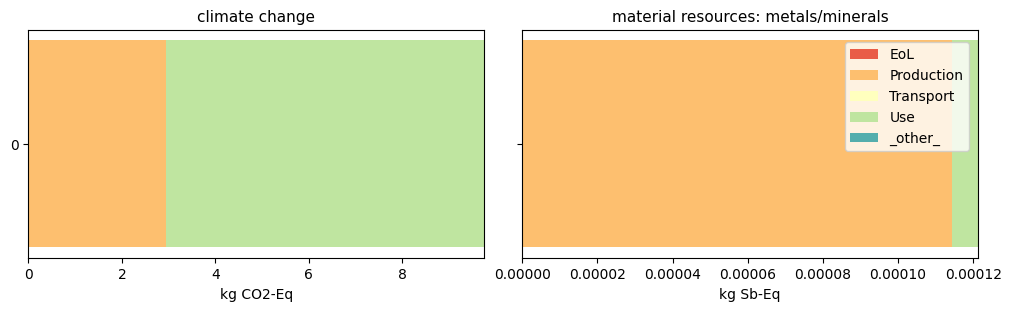

In [ ]:
### ------------------------------------------------------------------
# 1.  Set-up
# ------------------------------------------------------------------
df = df_impacts_axis.drop(index="*sum*")                    # convenience alias
labels = df.index                       # contribution labels (rows)
categories = df.columns                 # the two impact categories
palette = sns.color_palette("Spectral", n_colors=len(labels))

# ------------------------------------------------------------------
# 2.  Create a 1-by-N grid of sub-plots (one per impact category)
# ------------------------------------------------------------------
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(categories),
    figsize=(10, 3),
    sharey=True,                 # keep the single y tick aligned
    constrained_layout=True
)

# ------------------------------------------------------------------
# 3.  Draw a stacked horizontal bar in *each* subplot
# ------------------------------------------------------------------
for ax, cat in zip(axes, categories):
    left = 0
    for color, (label, value) in zip(palette, df[cat].items()):
        ax.barh(
            y=0,                 # only one device
            width=value,
            left=left,
            height=0.6,
            color=color,
            label=label
        )
        left += value            # accumulate for stacking

    # --- Cosmetics -------------------------------------------------
    # Shorten the subplot title to everything before the first " - "
    ax.set_title(cat.split(' - ')[0], fontsize=11)

    # Label the x-axis with the unit text (text inside the brackets)
    unit = cat.split('[')[-1].rstrip(']')
    ax.set_xlabel(unit)
    ax.set_yticks([0])

# ------------------------------------------------------------------
# 4.  One shared legend and overall title
# ------------------------------------------------------------------
fig.legend(labels, loc='upper right', ncol=1, bbox_to_anchor=(0.97, 0.9))
#fig.suptitle('Contribution analysis — single device', y=1.15, fontsize=14)
#plt.savefig(os.path.join(output_folder,"fig_"+contribution_analysis_label+"_"+selected_foreground+".png"))
plt.show()

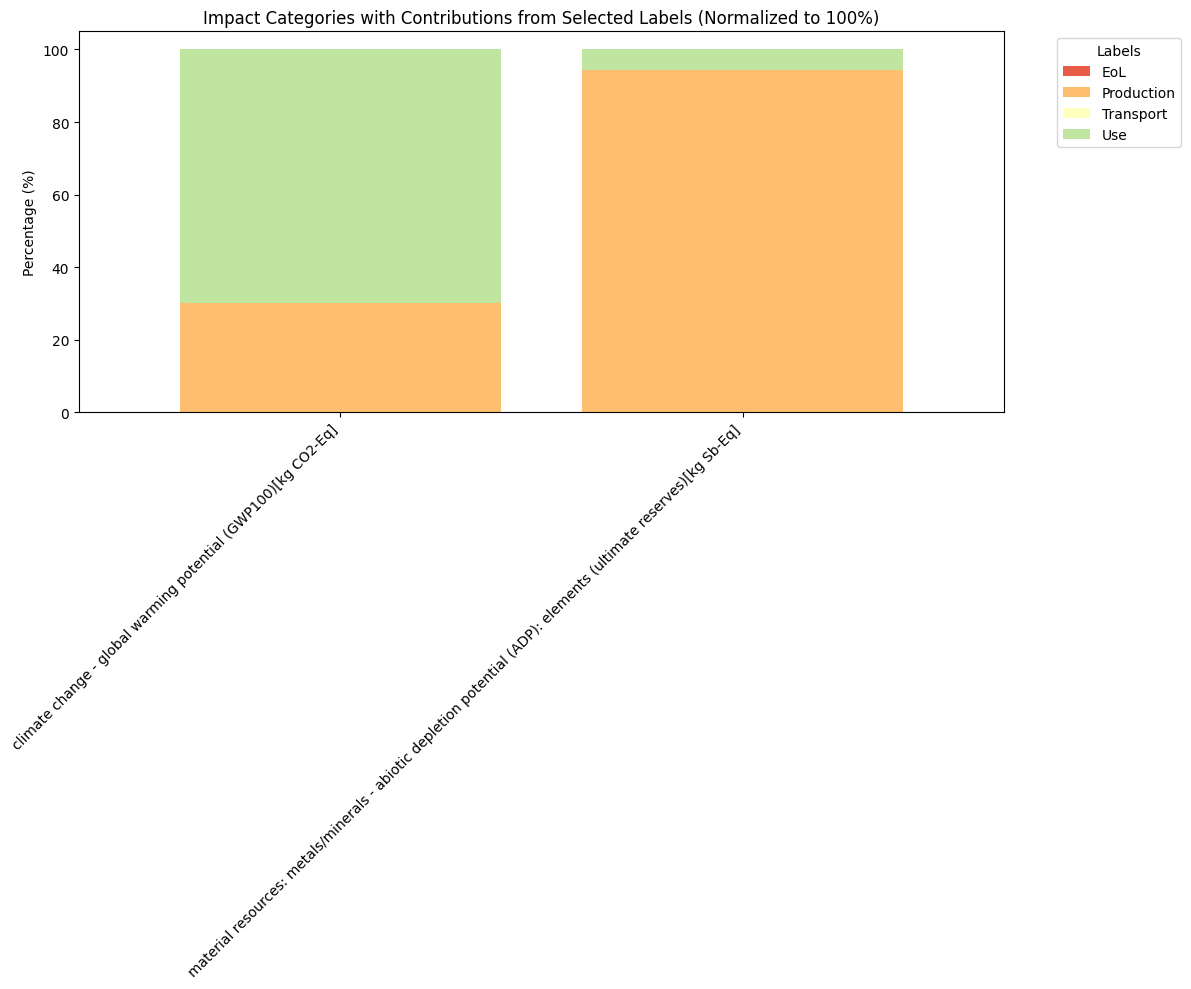

In [ ]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))
dark_palette = sns.color_palette("Spectral", n_colors=len(df_normalized.index))
df_normalized.T.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=dark_palette)
#dark_palette = sns.color_palette("Spectral", n_colors=len(df_impacts_axis_.index))
#df_impacts_axis_.T.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=dark_palette)

# Customize plot
ax.set_title('Impact Categories with Contributions from Selected Labels (Normalized to 100%)')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(df_impacts_axis_.columns, rotation=45, ha='right')
ax.legend(title="Labels", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(os.path.join(output_folder,"figure","fig_normalized_"+contribution_analysis_label+"_"+selected_foreground+".png"))
plt.show()

# Monte-Carlo Analysis

[WARNING] Param 'capacitor_smd_0603_mass_ceramic' is marked as FIXED, but passed in parameters : ignored
[WARNING] Param 'capacitor_smd_0603_mass_tantalum' is marked as FIXED, but passed in parameters : ignored
[WARNING] Param 'resistor_smd_0805_mass_copper' is marked as FIXED, but passed in parameters : ignored
[INFO] Db changed recently, clearing cache expr


Generating samples ...
Transforming samples ...


[INFO] Db changed recently, clearing cache lcia


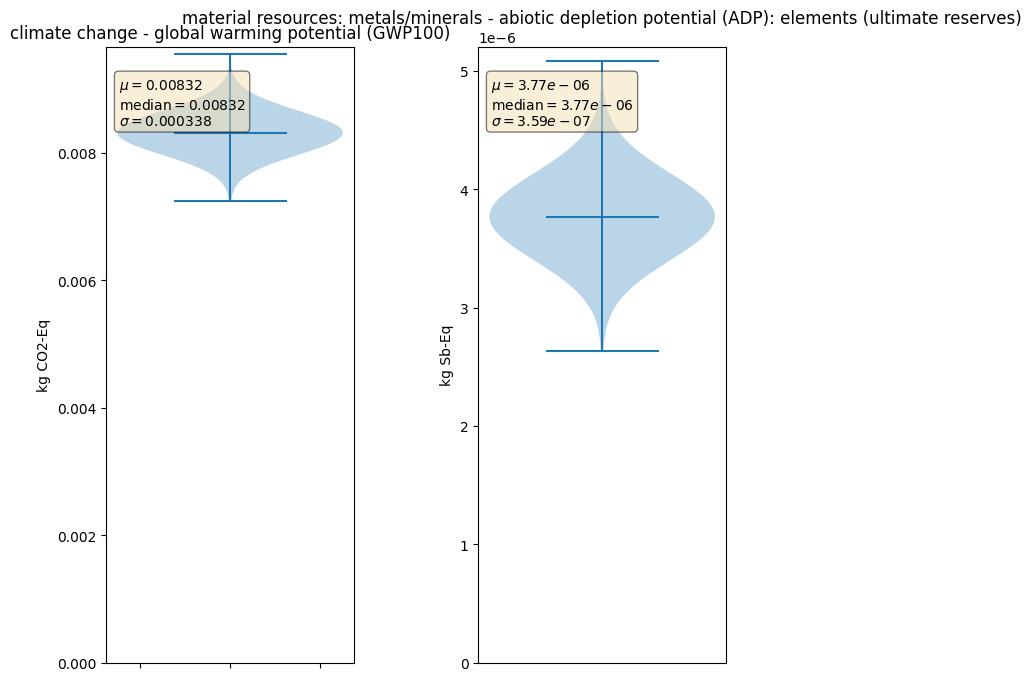

In [ ]:
MC_runs=agb.incer_stochastic_violin(agb.findActivity('capacitor_smd_0603', db_name= "OS database"), LCIA_method_list, functional_unit=1, figspace=(0.5,0.5), n=512, figsize=(8, 8), sharex=True,  nb_cols=2)

# Exporting results

In [ ]:
#output_file = os.path.join(output_folder,  selected_foreground+"_contribution_results.xlsx")
#df_impacts_axis.to_excel(output_file, index=True)
#print(f"Impact saved to {output_file}")